# Ia型超新星宇宙学参数后验估计：负对数似然 vs 归一化流

## 1. 背景介绍

**Ia型超新星（SNe Ia）** 是宇宙学中重要的"标准烛光". 通过测量它们的距离模数，我们可以约束宇宙学参数。

本notebook比较了两种估计 **后验分布** 宇宙学参数的方法：

### 方法对比：

1. **负对数似然（NLL）+ 高斯假设**
   - 假设后验分布为高斯分布
   - 网络输出均值和方差
   - 使用负对数似然作为损失函数

2. **Normalizing Flows (NF)**
   - 无特定分布假设
   - 学习从简单分布到复杂后验的可逆变换
   - 可以捕捉多峰分布, 非对称分布
   - 使用 `zuko` 库

### 任务类型：后验分布估计（不确定性量化）
- 输入：一维超新星距离模数序列
- 输出：宇宙学参数的后验分布

## 2. 安装和导入库

In [1]:
# 安装 zuko (if not already installed)
# !pip install zuko

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import time

# Normalizing flow library
import zuko
from lampe.inference import NPE
from lampe.nn import ResMLP
from lampe.inference import NPE, NPELoss
LAMPE_AVAILABLE = True
from lampe.utils import GDStep

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 3. 生成模拟超新星数据

我们模拟了超新星距离模量随红移的变化，并试图推断出宇宙参数:
- **$H_0$**: 哈勃常数
- **$\Omega_mw$**: 物质密度

$\Lambda$CDM模型中, 距离模数$\mu(z)$和这些量有关.

In [3]:
def simulate_distance_modulus(z, Omega_m, w, H0=70.0):
    """
    Simplified simulation of supernova distance modulus
    
    Parameters:
    - z: redshift array
    - Omega_m: matter density parameter (0.1-0.5)
    - w: dark energy equation of state (-1.5 to -0.5)
    - H0: Hubble constant
    
    Returns:
    - mu: distance modulus
    """
    # Simplified distance-redshift relation
    c = 299792.458  # km/s
    
    # Luminosity distance (simplified approximation)
    Omega_de = 1 - Omega_m
    
    # Numerical integration for comoving distance
    n_int = 100
    dL = np.zeros_like(z)
    
    for i, zi in enumerate(z):
        z_int = np.linspace(0, zi, n_int)
        dz = zi / n_int
        
        # E(z) = H(z)/H0
        E_z = np.sqrt(Omega_m * (1 + z_int)**3 + Omega_de * (1 + z_int)**(3*(1+w)))
        
        # Comoving distance
        dc = c / H0 * np.trapz(1.0 / E_z, z_int)
        
        # Luminosity distance
        dL[i] = (1 + zi) * dc
    
    # Distance modulus
    mu = 5 * np.log10(dL) + 25
    
    return mu

In [4]:
import numpy as np
from astropy.cosmology import w0waCDM
from scipy.constants import c
import matplotlib.pyplot as plt
import pandas as pd
c_kms = c / 1000  # km/s

# ========== 数据加载与模拟类 ==========

class CosmologyData:
    """
    宇宙学数据处理类：支持加载真实数据或生成模拟数据
    """
    def __init__(self, H0=70.0, Om0=0.3, w0=-1.0,wa = 0, Tcmb0=2.725,Ok0 = 0):
        """
        初始化宇宙学参数
        
        参数:
            H0: 哈勃常数 [km/s/Mpc]
            Om0: 物质密度参数
            w0: 暗能量状态方程参数
            Tcmb0: CMB温度 [K]
        """
        self.H0 = H0
        self.Om0 = Om0
        self.w0 = w0
        self.Tcmb0 = Tcmb0
        
        # 创建宇宙学模型
        self.cosmo = w0waCDM(H0=H0, Om0=Om0, Ode0=1-Om0-Ok0, 
                             w0=w0, wa=wa, Tcmb0=Tcmb0)
        
        self.bao_data = None
        self.sn_data = None
    
    # ========== BAO 数据处理 ==========
    
    def load_bao_from_file(self, filepath, columns=(0, 1, 2), skiprows=0):
        """
        从文件加载真实BAO数据
        
        参数:
            filepath: 数据文件路径或URL
            columns: (z列, DV/rd列, error列)
            skiprows: 跳过的行数
        
        返回:
            z, DV_rd, DV_rd_err
        """
        data = np.loadtxt(filepath, usecols=columns, skiprows=skiprows)
        self.bao_data = {
            'z': data[:, 0],
            'DV_rd': data[:, 1],
            'DV_rd_err': data[:, 2],
            'source': 'real'
        }
        return self.bao_data['z'], self.bao_data['DV_rd'], self.bao_data['DV_rd_err']
    
    def load_bao_desi_y1(self):
        """
        加载DESI Year 1 BAO数据（内置）
        """
        # DESI Y1数据点
        desi1_bgs_DVrd =      [0.295, 7.93, 0.15]
        desi1_lrg1_DMrdDHrd = [0.510, 13.62, 0.25, 20.98, 0.61, -0.445]
        desi1_lrg2_DMrdDHrd = [0.706, 16.85, 0.32, 20.08, 0.60, -0.420]
        desi1_lrg3_DMrdDHrd = [0.930, 21.71, 0.28, 17.88, 0.35, -0.389]
        desi1_elg2_DMrdDHrd = [1.317, 27.79, 0.69, 13.82, 0.42, -0.444]
        desi1_qso_DVrd =      [1.491, 26.07, 0.67]
        desi1_lya_DMrdDHrd =  [2.330, 39.71, 0.94, 8.52, 0.17, -0.477]

        def get_DVrd_fromDMDH(x):
            """将DM/rd, DH/rd转换为DV/rd"""
            z, A, dA, B, dB, r = x
            f = (z * (A**2) * B)**(1/3)
            dfdA = (2/3) * A * B * z / (f**2)
            dfdB = f / (3 * B)
            cov_AB = r * dA * dB
            delta_f = np.sqrt((dfdA * dA)**2 + (dfdB * dB)**2 + 2 * dfdA * dfdB * cov_AB)
            return [z, f, delta_f]

        # 将所有数据转换为DV/rd格式
        desi_data_list = []

        # BGS (已经是DV/rd格式)
        desi_data_list.append(desi1_bgs_DVrd)
        # LRG1
        lrg1_DVrd = get_DVrd_fromDMDH(desi1_lrg1_DMrdDHrd)
        desi_data_list.append(lrg1_DVrd)
        # LRG2
        lrg2_DVrd = get_DVrd_fromDMDH(desi1_lrg2_DMrdDHrd)
        desi_data_list.append(lrg2_DVrd)
        # LRG3
        lrg3_DVrd = get_DVrd_fromDMDH(desi1_lrg3_DMrdDHrd)
        desi_data_list.append(lrg3_DVrd)
        # ELG2
        elg2_DVrd = get_DVrd_fromDMDH(desi1_elg2_DMrdDHrd)
        desi_data_list.append(elg2_DVrd)
        # QSO (已经是DV/rd格式)
        desi_data_list.append(desi1_qso_DVrd)
        # LYA
        lya_DVrd = get_DVrd_fromDMDH(desi1_lya_DMrdDHrd)
        desi_data_list.append(lya_DVrd)
        # 转换为numpy矩阵
        desi_matrix = np.array(desi_data_list)

        z         = desi_matrix[:,0]
        DV_rd     = desi_matrix[:,1]
        DV_rd_err = desi_matrix[:,2]
        
        self.bao_data = {
            'z': z,
            'DV_rd': DV_rd,
            'DV_rd_err': DV_rd_err,
            'source': 'DESI_Y1'
        }
        return z, DV_rd, DV_rd_err
    
    def simulate_bao_from_real(self, use_loaded_data=True, rd_fid=147.46, seed=None):
        """
        基于真实数据的红移点和误差，生成模拟BAO观测
        
        参数:
            use_loaded_data: 是否使用已加载的真实数据的红移和误差
            rd_fid: 声学视界尺度
            seed: 随机种子
        
        返回:
            z_mock, DV_rd_mock, DV_rd_err
        """
        if seed is not None:
            np.random.seed(seed)
        
        if use_loaded_data and self.bao_data is not None:
            z = self.bao_data['z']
            DV_rd_err = self.bao_data['DV_rd_err']
        else:
            # 使用默认的DESI Y1红移点和误差
            self.load_bao_desi_y1()
            z = self.bao_data['z']
            DV_rd_err = self.bao_data['DV_rd_err']
        
        # 计算当前宇宙学模型的理论值
        DV_rd_theory = self._compute_DV_rd(z, rd_fid)
        
        # 添加高斯噪声
        DV_rd_mock = np.random.normal(loc=DV_rd_theory, scale=DV_rd_err)
        
        self.bao_data = {
            'z': z,
            'DV_rd': DV_rd_mock,
            'DV_rd_err': DV_rd_err,
            'source': 'simulated'
        }
        
        return z, DV_rd_mock, DV_rd_err
    
    def _compute_DV_rd(self, z, rd_fid=147.46):
        """计算BAO理论值 DV/rd"""
        dHz = c_kms / self.cosmo.H(z).value
        dMz = self.cosmo.luminosity_distance(z).value / (1 + z)
        return ((z * (dMz**2) * dHz)**(1/3)) / rd_fid
    
    # ========== 超新星数据处理 ==========
    
    def load_sn_from_file(self, filepath, columns=(0, 1, 2), skiprows=0):
        """
        从文件加载真实超新星数据
        
        参数:
            filepath: 数据文件路径或URL
            columns: (z列, μ列, error列)
            skiprows: 跳过的行数
        
        返回:
            z, mu, mu_err
        """
        data = pd.read_csv(filepath, delim_whitespace=True)
        z, mu, mu_err = data['zHD'].values, data['MU_SH0ES'].values, data['MU_SH0ES_ERR_DIAG'].values
        self.sn_data = {
            'z': z,
            'mu': mu,
            'mu_err': mu_err,
            'source': 'real'
        }
        return self.sn_data['z'], self.sn_data['mu'], self.sn_data['mu_err']
    
    def load_sn_pantheon_plus(self):
        """
        加载Pantheon+ 超新星数据（从在线源）
        """
        url = 'https://github.com/PantheonPlusSH0ES/DataRelease/raw/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat'
        
        try:
            data = np.loadtxt(url, skiprows=1, usecols=(2, 10, 11))
            # 跳过前111个Cepheid数据点
            z = data[:, 0][111:]
            mu = data[:, 1][111:]
            mu_err = data[:, 2][111:]
            
            self.sn_data = {
                'z': z,
                'mu': mu,
                'mu_err': mu_err,
                'source': 'Pantheon+'
            }
            return z, mu, mu_err
        except Exception as e:
            print(f"无法加载Pantheon+数据: {e}")
            print("使用模拟数据替代...")
            return self.simulate_sn_data()
    
    def simulate_sn_from_real(self, use_loaded_data=True, seed=None):
        """
        基于真实数据的红移点和误差，生成模拟超新星观测
        
        参数:
            use_loaded_data: 是否使用已加载的真实数据的红移和误差
            seed: 随机种子
        
        返回:
            z_mock, mu_mock, mu_err
        """
        if seed is not None:
            np.random.seed(seed)
        
        if use_loaded_data and self.sn_data is not None:
            z = self.sn_data['z']
            mu_err = self.sn_data['mu_err']
        else:
            # 创建默认的红移网格和误差
            z = np.logspace(-2, 0.5, 50)
            mu_err = 0.12 + 0.08 * np.log10(1 + z)
        
        # 计算当前宇宙学模型的理论值
        mu_theory = self.cosmo.distmod(z).value
        
        # 添加高斯噪声
        mu_mock = np.random.normal(loc=mu_theory, scale=mu_err)
        
        self.sn_data = {
            'z': z,
            'mu': mu_mock,
            'mu_err': mu_err,
            'source': 'simulated'
        }
        
        return z, mu_mock, mu_err
    
    def simulate_sn_data(self, n_points=50, z_range=(0.01, 3.0), seed=None):
        """
        生成完全模拟的超新星数据（自定义红移范围和点数）
        """
        if seed is not None:
            np.random.seed(seed)
        
        z = np.logspace(np.log10(z_range[0]), np.log10(z_range[1]), n_points)
        mu_err = 0.12 + 0.08 * np.log10(1 + z)
        mu_theory = self.cosmo.distmod(z).value
        mu_mock = np.random.normal(loc=mu_theory, scale=mu_err)
        
        self.sn_data = {
            'z': z,
            'mu': mu_mock,
            'mu_err': mu_err,
            'source': 'simulated'
        }
        
        return z, mu_mock, mu_err
    
    # ========== 绘图功能 ==========
    
    def plot_data(self, figsize=(14, 5)):
        """绘制BAO和超新星数据"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # 绘制BAO数据
        if self.bao_data is not None:
            z_bao = self.bao_data['z']
            DV_rd = self.bao_data['DV_rd']
            DV_rd_err = self.bao_data['DV_rd_err']
            
            # 绘制数据点
            ax1.errorbar(z_bao, DV_rd / (z_bao**(2/3)), 
                        yerr=DV_rd_err / (z_bao**(2/3)),
                        fmt='o', label=f"Data ({self.bao_data['source']})",
                        markersize=6, capsize=3)
            
            # 绘制理论曲线
            z_theory = np.linspace(z_bao.min(), z_bao.max(), 100)
            DV_rd_theory = self._compute_DV_rd(z_theory)
            ax1.plot(z_theory, DV_rd_theory / (z_theory**(2/3)), 
                    'r-', alpha=0.7, label=f'Theory (H₀={self.H0}, Ωₘ={self.Om0}, w={self.w0})')
            
            ax1.set_xlabel('Redshift z', fontsize=12)
            ax1.set_ylabel(r'$D_V / (r_D z^{2/3})$', fontsize=12)
            ax1.set_title('BAO Observations', fontsize=13, fontweight='bold')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        
        # 绘制超新星数据
        if self.sn_data is not None:
            z_sn = self.sn_data['z']
            mu = self.sn_data['mu']
            mu_err = self.sn_data['mu_err']
            
            # 数据点
            ax2.errorbar(z_sn, mu, yerr=mu_err,
                        fmt='o', markersize=3, alpha=0.5,
                        label=f"Data ({self.sn_data['source']})", capsize=2)
            
            # 理论曲线
            z_theory = np.logspace(np.log10(z_sn.min()), np.log10(z_sn.max()), 100)
            mu_theory = self.cosmo.distmod(z_theory).value
            ax2.plot(z_theory, mu_theory, 
                    'r-', alpha=0.7, label=f'Theory (H₀={self.H0}, Ωₘ={self.Om0}, w={self.w0})')
            
            ax2.set_xlabel('Redshift z', fontsize=12)
            ax2.set_ylabel('Distance Modulus μ', fontsize=12)
            ax2.set_title('Supernova Observations', fontsize=13, fontweight='bold')
            ax2.set_xscale('log')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig, (ax1, ax2)
    
    def print_summary(self):
        """打印数据摘要"""
        print("=" * 60)
        print("宇宙学数据摘要")
        print("=" * 60)
        print(f"宇宙学参数: H₀={self.H0:.1f} km/s/Mpc, Ωₘ={self.Om0:.3f}, w={self.w0:.2f}")
        print()
        
        if self.bao_data is not None:
            print(f"BAO数据: {len(self.bao_data['z'])} 个数据点")
            print(f"  来源: {self.bao_data['source']}")
            print(f"  红移范围: {self.bao_data['z'].min():.3f} - {self.bao_data['z'].max():.3f}")
            print(f"  误差范围: {self.bao_data['DV_rd_err'].min():.3f} - {self.bao_data['DV_rd_err'].max():.3f}")
        else:
            print("BAO数据: 未加载")
        
        print()
        
        if self.sn_data is not None:
            print(f"超新星数据: {len(self.sn_data['z'])} 个数据点")
            print(f"  来源: {self.sn_data['source']}")
            print(f"  红移范围: {self.sn_data['z'].min():.4f} - {self.sn_data['z'].max():.3f}")
            print(f"  误差范围: {self.sn_data['mu_err'].min():.3f} - {self.sn_data['mu_err'].max():.3f} mag")
        else:
            print("超新星数据: 未加载")
        
        print("=" * 60)

In [5]:
import numpy as np
from numba import jit, prange
from tqdm import tqdm

# ========== numba加速距离模量计算 ==========
@jit(nopython=True, parallel=True)
def compute_mu_batch(H0_arr, Om0_arr, z_obs, n_int=100):
    """
    并行计算多个宇宙论的距离模量，使用numba加速倍。
    """
    c = 299792.458  # km/s
    n_samples = len(H0_arr)
    n_z = len(z_obs)
    
    mu_all = np.zeros((n_samples, n_z))
    
    for i in prange(n_samples):  # Parallel loop
        H0 = H0_arr[i]
        Om0 = Om0_arr[i]
        Ode0 = 1.0 - Om0
        
        for j in range(n_z):
            z = z_obs[j]
            
            # Numerical integration using trapezoid rule
            z_int = np.linspace(0.0, z, n_int)
            
            # E(z) = H(z)/H0 for flat ΛCDM (w=-1)
            E_z = np.sqrt(Om0 * (1.0 + z_int)**3 + Ode0)
            
            # Comoving distance integral: dc = (c/H0) * ∫ dz/E(z)
            integrand = 1.0 / E_z
            dc = c / H0 * np.trapz(integrand, z_int)
            
            # Luminosity distance and distance modulus
            dL = (1.0 + z) * dc
            mu_all[i, j] = 5.0 * np.log10(dL) + 25.0
    
    return mu_all

@jit(nopython=True)
def add_gaussian_noise_batch(mu_theory, mu_err, n_samples):
    """添加高斯噪声"""
    result = np.zeros_like(mu_theory)
    for i in range(n_samples):
        for j in range(mu_theory.shape[1]):
            result[i, j] = mu_theory[i, j] + np.random.randn() * mu_err[j]
    return result

# ========== Main simulation ==========
n_samples = 200000

# Load data once
temp_cosmo = CosmologyData()
temp_cosmo.load_sn_from_file('./Pantheon+SH0ES.dat')
z_obs = temp_cosmo.sn_data['z']
mu_err_obs = temp_cosmo.sn_data['mu_err']

# Sample parameters
H0_low, H0_up = (50, 90)
Om0_low, Om0_up = (0.1, 0.5)
H0_samples = np.random.uniform(H0_low, H0_up, n_samples)
Om0_samples = np.random.uniform(Om0_low, Om0_up, n_samples)

# Compute all distance moduli at once (first call compiles, subsequent calls are fast)
print("Computing distance moduli (first call includes JIT compilation)...")
mu_theory = compute_mu_batch(H0_samples, Om0_samples, z_obs, n_int=100)

# Add noise
print("Adding Gaussian noise...")
np.random.seed(42)  # For reproducibility
X = add_gaussian_noise_batch(mu_theory, mu_err_obs, n_samples)

theta = np.stack((H0_samples, Om0_samples), axis=1)
n_sn = X.shape[1]

print(f"Generated {n_samples} samples with {n_sn} data points each")

Computing distance moduli (first call includes JIT compilation)...
Adding Gaussian noise...
Generated 200000 samples with 1701 data points each


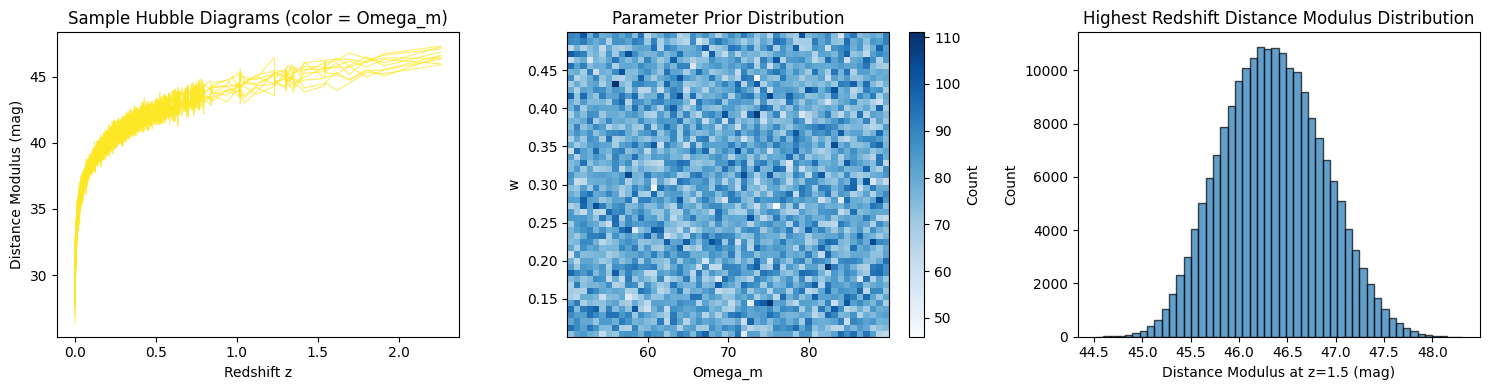

In [6]:
# 可视化 data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 绘图 some Hubble diagrams
ax = axes[0]
for i in range(10):
    color = plt.cm.viridis(theta[i, 0] / 0.5)  # Color by Omega_m
    ax.plot(z_obs, X[i], alpha=0.7, color=color, linewidth=0.8)
ax.set_xlabel('Redshift z')
ax.set_ylabel('Distance Modulus (mag)')
ax.set_title('Sample Hubble Diagrams (color = Omega_m)')

# Parameter distribution
ax = axes[1]
ax.hist2d(theta[:, 0], theta[:, 1], bins=50, cmap='Blues')
ax.set_xlabel('Omega_m')
ax.set_ylabel('w')
ax.set_title('Parameter Prior Distribution')
plt.colorbar(ax.collections[0], ax=ax, label='Count')

# Distance modulus distribution
ax = axes[2]
ax.hist(X[:, -1], bins=50, alpha=0.7, edgecolor='black')
ax.set_xlabel('Distance Modulus at z=1.5 (mag)')
ax.set_ylabel('Count')
ax.set_title('Highest Redshift Distance Modulus Distribution')

plt.tight_layout()
plt.show()

## 4. 数据预处理

In [7]:
# Standardize data
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_normalized = (X - X_mean) / X_std

LOWER = np.array([H0_low, Om0_low])
UPPER = np.array([H0_up, Om0_up])

def preprocess(theta: torch.Tensor) -> torch.Tensor:
    return 2 * (theta - LOWER) / (UPPER - LOWER) - 1

def postprocess(theta: torch.Tensor) -> torch.Tensor:
    return (theta + 1) / 2 * (UPPER - LOWER) + LOWER

# theta_mean = theta.mean(axis=0)
# theta_std = theta.std(axis=0)
theta_normalized = preprocess(theta)#(theta - theta_mean) / theta_std

# print(f'X normalization: mean={X_mean.mean():.3f}, std={X_std.mean():.3f}')
print(f'theta normalization:')
# print(f'  Omega_m: mean={theta_mean[0]:.3f}, std={theta_std[0]:.3f}')
# print(f'  w: mean={theta_mean[1]:.3f}, std={theta_std[1]:.3f}')

theta normalization:


In [8]:
# 训练-test split
X_train, X_test, theta_train, theta_test = train_test_split(
    X_normalized, theta_normalized, test_size=0.2, random_state=42
)

# Original scale test set (for evaluation)
_, _, theta_train_orig, theta_test_orig = train_test_split(
    X_normalized, theta, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train)} samples')
print(f'Test set: {len(X_test)} samples')

Training set: 160000 samples
Test set: 40000 samples


In [9]:
# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
theta_train_t = torch.FloatTensor(theta_train)
theta_test_t = torch.FloatTensor(theta_test)

# 创建 DataLoader
batch_size = 1024 * 32
train_dataset = TensorDataset(X_train_t, theta_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f'Batch size: {batch_size}')
print(f'Number of batches per epoch: {len(train_loader)}')

Batch size: 32768
Number of batches per epoch: 5


## 5. Method 1: NLL Loss (网络高斯近似)

### Principle

假设参数的后验分布是高斯分布:
$$p(\theta | x) = \mathcal{N}(\mu(x), \sigma^2(x))$$

网络输出:
- 均值$\mu(x)$
- 对数方差 $\log\sigma^2(x)$

损失函数（高斯负对数似然）:
$$\mathcal{L} = \frac{1}{2}\log\sigma^2 + \frac{(\theta - \mu)^2}{2\sigma^2}$$

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CorrelatedGaussianNLLNetwork(nn.Module):
    """
    Network for correlated Gaussian posterior estimation.
    Outputs:
    - mean vector: (batch, d)
    - Cholesky factor L of covariance matrix Sigma = L L^T
    """

    def __init__(self, input_dim, output_dim, hidden_dims=[256, 128, 64], dropout=0.1):
        super().__init__()
        self.output_dim = output_dim
        self.n_tril = output_dim * (output_dim + 1) // 2  # number of lower-triangular entries

        # Shared feature extractor
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)

        # Mean head
        self.mean_head = nn.Linear(prev_dim, output_dim)

        # Cholesky head: outputs lower-triangular parameters
        self.cholesky_head = nn.Linear(prev_dim, self.n_tril)

    def _build_cholesky(self, raw_tril):
        """
        Convert raw lower-triangular parameters into a valid Cholesky factor L.
        Diagonal entries are forced positive via softplus.
        
        raw_tril: (batch, n_tril)
        returns: L of shape (batch, d, d)
        """
        batch_size = raw_tril.shape[0]
        d = self.output_dim
        L = raw_tril.new_zeros(batch_size, d, d)

        tril_indices = torch.tril_indices(row=d, col=d, offset=0)
        L[:, tril_indices[0], tril_indices[1]] = raw_tril

        # Force diagonal positive for positive-definite covariance
        diag_idx = torch.arange(d, device=raw_tril.device)
        L[:, diag_idx, diag_idx] = F.softplus(L[:, diag_idx, diag_idx]) + 1e-6

        return L

    def forward(self, x):
        features = self.feature_extractor(x)
        mean = self.mean_head(features)
        raw_tril = self.cholesky_head(features)
        L = self._build_cholesky(raw_tril)
        return mean, L

    def covariance_matrix(self, x):
        """
        Return full covariance matrix Sigma = L L^T
        """
        self.eval()
        with torch.no_grad():
            _, L = self.forward(x)
            Sigma = L @ L.transpose(-1, -2)
        return Sigma

    def sample(self, x, n_samples=1000):
        """
        Sample from predicted correlated Gaussian posterior.
        
        Returns:
            samples: (batch, n_samples, d)
        """
        self.eval()
        with torch.no_grad():
            mean, L = self.forward(x)  # mean: (batch, d), L: (batch, d, d)
            batch_size, d = mean.shape

            eps = torch.randn(batch_size, n_samples, d, device=mean.device)  # standard normal
            # samples = mean + L @ eps
            samples = mean.unsqueeze(1) + torch.matmul(eps, L.transpose(1, 2))

        return samples

In [11]:
def correlated_gaussian_nll_loss(mean, L, target):
    """
    Multivariate Gaussian negative log-likelihood loss.

    Parameters:
    - mean:   (batch, d)
    - L:      (batch, d, d), Cholesky factor of covariance
    - target: (batch, d)
    """
    dist = torch.distributions.MultivariateNormal(loc=mean, scale_tril=L)
    nll = -dist.log_prob(target)  # (batch,)
    return nll.mean()

In [12]:
# 创建 NLL model
input_dim = n_sn
output_dim = 2  # Omega_m and w

nll_model = CorrelatedGaussianNLLNetwork(input_dim=input_dim, output_dim=2).to(device)

# Count parameters
n_params_nll = sum(p.numel() for p in nll_model.parameters() if p.requires_grad)
print(f'NLL Model Parameters: {n_params_nll:,}')
print(nll_model)

NLL Model Parameters: 478,085
CorrelatedGaussianNLLNetwork(
  (feature_extractor): Sequential(
    (0): Linear(in_features=1701, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
  )
  (mean_head): Linear(in_features=64, out_features=2, bias=True)
  (cholesky_head): Linear(in_features=64, out_features=3, bias=True)
)


In [13]:
# 训练ing NLL model
optimizer = optim.AdamW(nll_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

n_epochs = 500
train_losses_nll = []
test_losses_nll = []


# 早停配置
best_test_loss = float('inf')
patience_counter = 0
early_stop_patience = 30

print('Training NLL Model...')
print('-' * 50)

start_time = time.time()

for epoch in range(n_epochs):
    # 训练ing
    nll_model.train()
    epoch_loss = 0
    
    for batch_x, batch_theta in train_loader:
        batch_x = batch_x.to(device)
        batch_theta = batch_theta.to(device)
        
        optimizer.zero_grad()
        mean, L = nll_model(batch_x)
        loss = correlated_gaussian_nll_loss(mean, L, batch_theta)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    
    train_loss = epoch_loss / len(train_loader)
    train_losses_nll.append(train_loss)
    
    # 测试ing
    nll_model.eval()
    with torch.no_grad():
        mean, L = nll_model(X_test_t.to(device))
        test_loss = correlated_gaussian_nll_loss(mean, L, theta_test_t.to(device)).item()
        
        
    test_losses_nll.append(test_loss)
    
    scheduler.step(test_loss)
    
    # 早停检查
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        torch.save(nll_model.state_dict(), 'best_nll_model.pt')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{n_epochs}] Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Patience: {patience_counter}/{early_stop_patience}')
    
    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

nll_train_time = time.time() - start_time
print('-' * 50)
print(f'NLL model training time: {nll_train_time:.2f} seconds')
print(f'Best test loss: {best_test_loss:.4f}')

# 加载最佳模型
nll_model.load_state_dict(torch.load('best_nll_model.pt'))

Training NLL Model...
--------------------------------------------------
Epoch [ 20/500] Train Loss: -1.5255 | Test Loss: -1.9639 | Patience: 0/30
Epoch [ 40/500] Train Loss: -2.2552 | Test Loss: -2.9019 | Patience: 0/30
Epoch [ 60/500] Train Loss: -2.3677 | Test Loss: -2.9892 | Patience: 0/30
Epoch [ 80/500] Train Loss: -2.4264 | Test Loss: -3.0429 | Patience: 6/30
Epoch [100/500] Train Loss: -2.4591 | Test Loss: -3.0812 | Patience: 19/30
Epoch [120/500] Train Loss: -2.4865 | Test Loss: -3.0933 | Patience: 3/30
Epoch [140/500] Train Loss: -2.4915 | Test Loss: -3.0896 | Patience: 11/30
Epoch [160/500] Train Loss: -2.5000 | Test Loss: -3.1027 | Patience: 0/30
Epoch [180/500] Train Loss: -2.4959 | Test Loss: -3.1076 | Patience: 1/30
Epoch [200/500] Train Loss: -2.5047 | Test Loss: -3.1067 | Patience: 21/30
Early stopping at epoch 209
--------------------------------------------------
NLL model training time: 554.82 seconds
Best test loss: -3.1092


<All keys matched successfully>

## 6. Method 2: Normalizing Flows

### Principle

归一化流学习从简单基分布（如高斯分布）到复杂后验分布的可逆变换:

$$\theta = f(z; x), \quad z \sim \mathcal{N}(0, I)$$

通过:
$$\log p(\theta | x) = \log p(z) - \log |\det \frac{\partial f}{\partial z}|$$

**优势：**
- 没有特定的分布假设（不用写出似然函数）
- 可以捕捉多峰和非对称分布
- 可以捕捉参数相关性

In [14]:
# ===== 简单的ANN压缩网络 =====
class SimpleEmbedding(nn.Module):
    """
    简单的全连接压缩网络
    比ResNet简单，但可能够用！
    """
    def __init__(self, input_dim: int, embedding_dim: int = 16):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.0),
            
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.0),
            
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.0),
            
            nn.Linear(64, embedding_dim),
        )
    
    def forward(self, x):
        return self.network(x)


# ===== NPE + ANN Embedding =====
class NPEWithEmbedding(nn.Module):
    def __init__(self, theta_dim: int = 2, input_dim: int = 1686, 
                 embedding_dim: int = 16):
        super().__init__()

        # ANN Embedding
        self.embedding = SimpleEmbedding(input_dim, embedding_dim)
        
        # NPE Flow
        self.npe = NPE(
            theta_dim=theta_dim, 
            x_dim=embedding_dim, 
            build=zuko.flows.NSF, 
            hidden_features=[128] * 3, 
            transforms=5,
            activation=nn.ELU#nn.ReLU
        )

    def forward(self, theta: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return self.npe(theta, self.embedding(x))

    def flow(self, x: torch.Tensor):
        return self.npe.flow(self.embedding(x))



flow_model = NPEWithEmbedding(
        theta_dim=output_dim,      # 2
        input_dim=input_dim,       # 1686
        embedding_dim=128           # 压缩到32维
    ).to(device)


# Count parameters
n_params_flow = sum(p.numel() for p in flow_model.parameters() if p.requires_grad)

loss = NPELoss(flow_model)
print(f'Flow Model Parameters: {n_params_flow:,}')

Flow Model Parameters: 2,311,334


In [15]:
"""
添加学习率衰减和早停的训练代码
"""

import torch
import time
from lampe.utils import GDStep

# =============================================================================
# 训练配置
# =============================================================================

optimizer_flow = optim.AdamW(flow_model.parameters(), lr=1e-3)
step = GDStep(optimizer_flow, clip=1.0)

train_losses_flow = []
test_losses_flow = []

# 学习率衰减配置
lr_patience = 10  # N个epoch loss不下降就减半学习率
lr_decay_factor = 0.5  # 学习率衰减因子
min_lr = 1e-6  # 最小学习率

# 早停配置
early_stop_patience = 30  # 早停耐心值
min_delta = 1e-4  # 最小改进量（小于这个值认为没改进）

# 状态跟踪
best_test_loss = float('inf')
patience_counter = 0
lr_patience_counter = 0

print('Training NPE Flow Model...')
print('-' * 60)
print(f'Initial LR: {optimizer_flow.param_groups[0]["lr"]:.2e}')
print(f'LR Patience: {lr_patience} epochs')
print(f'Early Stop Patience: {early_stop_patience} epochs')
print('-' * 60)

start_time = time.time()
n_epochs = 500

for epoch in range(n_epochs):
    # ========== 训练 ==========
    flow_model.train()
    epoch_loss = 0
    losses = []
    
    for batch_x, batch_theta in train_loader:
        batch_x = batch_x.to(device)
        batch_theta = batch_theta.to(device)
        
        los = step(loss(batch_theta, batch_x))
        losses.append(los)
        epoch_loss += los.item()
    
    train_loss = epoch_loss / len(train_loader)
    train_losses_flow.append(train_loss)
    
    # ========== 验证 ==========
    flow_model.eval()
    with torch.no_grad():
        test_loss = loss(theta_test_t.cuda(), X_test_t.cuda()).mean().item()
    test_losses_flow.append(test_loss)
    
    # ========== 检查改进 ==========
    improved = False
    if test_loss < (best_test_loss - min_delta):
        # 有显著改进
        improvement = best_test_loss - test_loss
        best_test_loss = test_loss
        improved = True
        patience_counter = 0
        lr_patience_counter = 0
        
        # 保存最佳模型
        torch.save(flow_model.state_dict(), 'best_flow_model.pt')
    else:
        # 没有改进
        patience_counter += 1
        lr_patience_counter += 1
    
    # ========== 学习率衰减 ==========
    current_lr = optimizer_flow.param_groups[0]['lr']
    
    if lr_patience_counter >= lr_patience and current_lr > min_lr:
        new_lr = max(current_lr * lr_decay_factor, min_lr)
        for param_group in optimizer_flow.param_groups:
            param_group['lr'] = new_lr
        
        print(f'  → Learning rate reduced: {current_lr:.2e} → {new_lr:.2e}')
        lr_patience_counter = 0  # 重置计数器
    
    # ========== 打印进度 ==========
    if (epoch + 1) % 10 == 0 or improved:
        status = '✓' if improved else ' '
        print(f'{status} Epoch [{epoch+1:3d}/{n_epochs}] '
              f'Train: {train_loss:.4f} | Test: {test_loss:.4f} | '
              f'Best: {best_test_loss:.4f} | '
              f'LR: {current_lr:.2e} | '
              f'Patience: {patience_counter}/{early_stop_patience}')
    
    # ========== 早停检查 ==========
    if patience_counter >= early_stop_patience:
        print(f'\n早停触发！在 epoch {epoch+1}')
        print(f'Best test loss: {best_test_loss:.4f}')
        break

flow_train_time = time.time() - start_time

print('-' * 60)
print(f'训练完成！')
print(f'总时间: {flow_train_time:.2f} seconds')
print(f'最佳测试loss: {best_test_loss:.4f}')
print(f'训练了 {epoch+1} epochs')
print('-' * 60)

# 加载最佳模型
flow_model.load_state_dict(torch.load('best_flow_model.pt'))
print('✓ 已加载最佳模型')

Training NPE Flow Model...
------------------------------------------------------------
Initial LR: 1.00e-03
LR Patience: 10 epochs
Early Stop Patience: 30 epochs
------------------------------------------------------------
✓ Epoch [  1/500] Train: 1.6167 | Test: 0.9464 | Best: 0.9464 | LR: 1.00e-03 | Patience: 0/30
✓ Epoch [  7/500] Train: -1.7909 | Test: -0.3664 | Best: -0.3664 | LR: 1.00e-03 | Patience: 0/30
✓ Epoch [  8/500] Train: -1.5292 | Test: -1.5345 | Best: -1.5345 | LR: 1.00e-03 | Patience: 0/30
  Epoch [ 10/500] Train: -2.0037 | Test: -0.2317 | Best: -1.5345 | LR: 1.00e-03 | Patience: 2/30
✓ Epoch [ 12/500] Train: -1.7744 | Test: -1.9194 | Best: -1.9194 | LR: 1.00e-03 | Patience: 0/30
✓ Epoch [ 13/500] Train: -2.1920 | Test: -2.1325 | Best: -2.1325 | LR: 1.00e-03 | Patience: 0/30
✓ Epoch [ 14/500] Train: -2.4699 | Test: -2.2797 | Best: -2.2797 | LR: 1.00e-03 | Patience: 0/30
  Epoch [ 20/500] Train: -1.9861 | Test: -2.1479 | Best: -2.2797 | LR: 1.00e-03 | Patience: 6/30
✓ E

## 7. 结果比较

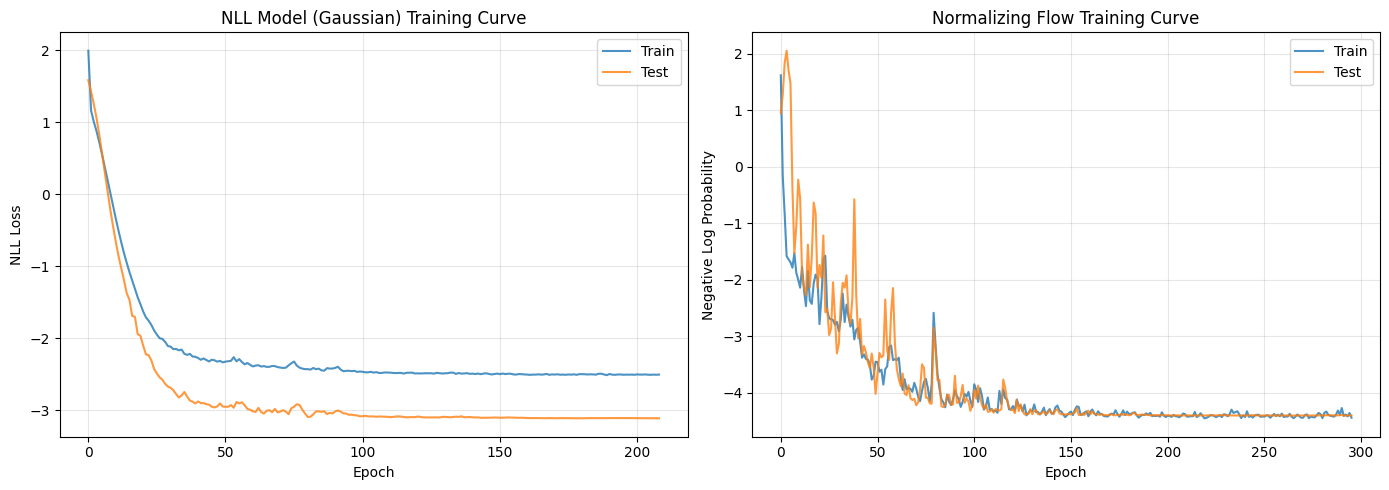

In [16]:
# 绘图 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NLL training curve
ax = axes[0]
ax.plot(train_losses_nll, label='Train', alpha=0.8)
ax.plot(test_losses_nll, label='Test', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('NLL Loss')
ax.set_title('NLL Model (Gaussian) Training Curve')
ax.legend()
ax.grid(True, alpha=0.3)

# Flow training curve
ax = axes[1]
if len(train_losses_flow) > 0:
    ax.plot(train_losses_flow, label='Train', alpha=0.8)
    ax.plot(test_losses_flow, label='Test', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Negative Log Probability')
    ax.set_title('Normalizing Flow Training Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'zuko not available', ha='center', va='center', fontsize=14)
    ax.set_title('Normalizing Flow (Not Available)')

plt.tight_layout()
plt.show()

In [17]:
# 生成 posterior samples
n_posterior_samples = 2**16

# Select some test samples
test_indices = [3, 100, 500, 1000]

# NLL samples
nll_model.eval()
X_selected = X_test_t[test_indices].to(device)
nll_samples = nll_model.sample(X_selected, n_samples=n_posterior_samples)
nll_samples = nll_samples.cpu().numpy()

# Denormalize
nll_samples = postprocess(nll_samples)#nll_samples * theta_std + theta_mean


flow_samples = []######注意lamep不支持批量操作########
for i in range(len(test_indices)):
    flow_model.eval()
    with torch.no_grad():
        samples = flow_model.flow(X_selected[i].reshape(1,-1)).sample((n_posterior_samples,))
        samples = samples.cpu().numpy()
        samples = postprocess(samples)#flow_samples * theta_std + theta_mean
    flow_samples.append(samples[:,0,:])
    
flow_samples = np.array(flow_samples)
# True values
true_values = theta_test_orig[test_indices]

print(f'Generated {n_posterior_samples} posterior samples for {len(test_indices)} test cases')

Generated 65536 posterior samples for 4 test cases


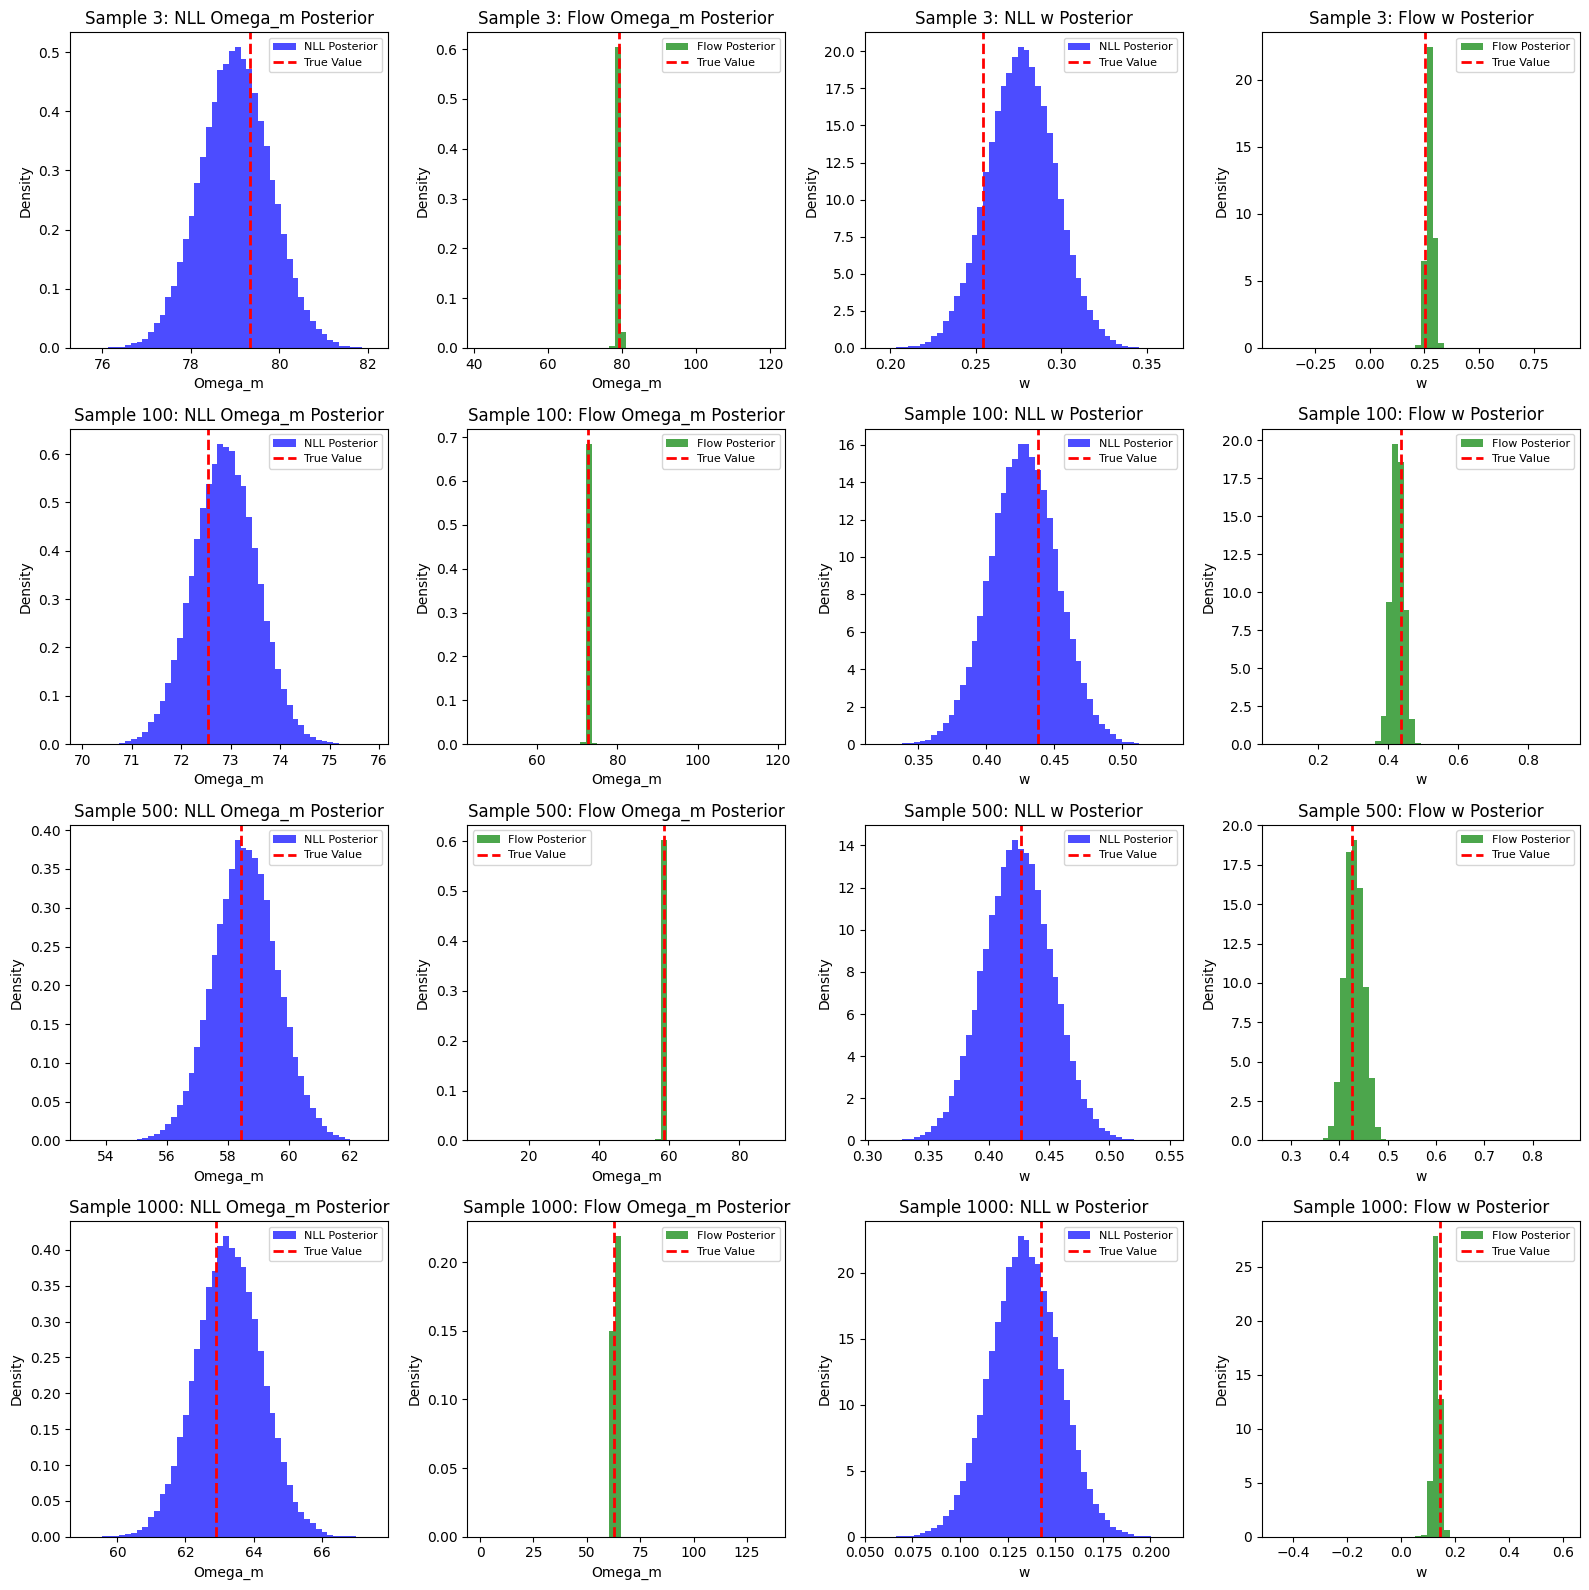

In [18]:
# 绘图 posterior distributions for selected test samples
fig, axes = plt.subplots(len(test_indices), 4, figsize=(16, 4*len(test_indices)))

param_names = ['Omega_m', 'w']
# param_ranges = [(-1.0, 0.5), (-1.5, -0.5)]

for i, idx in enumerate(test_indices):
    # Omega_m marginal - NLL
    ax = axes[i, 0]
    ax.hist(nll_samples[i, :, 0], bins=50, density=True, alpha=0.7, color='blue', label='NLL Posterior')
    ax.axvline(true_values[i, 0], color='red', linestyle='--', linewidth=2, label='True Value')
    ax.set_xlabel('Omega_m')
    ax.set_ylabel('Density')
    ax.set_title(f'Sample {idx}: NLL Omega_m Posterior')
    ax.legend(fontsize=8)
#     ax.set_xlim(param_ranges[0])
    
    # Omega_m marginal - Flow
    ax = axes[i, 1]
    if flow_samples is not None:
        ax.hist(flow_samples[i, :, 0], bins=50, density=True, alpha=0.7, color='green', label='Flow Posterior')
        ax.axvline(true_values[i, 0], color='red', linestyle='--', linewidth=2, label='True Value')
        ax.set_title(f'Sample {idx}: Flow Omega_m Posterior')
    else:
        ax.text(0.5, 0.5, 'Not Available', ha='center', va='center')
        ax.set_title(f'Sample {idx}: Flow (N/A)')
    ax.set_xlabel('Omega_m')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
#     ax.set_xlim(param_ranges[0])
    
    # w marginal - NLL
    ax = axes[i, 2]
    ax.hist(nll_samples[i, :, 1], bins=50, density=True, alpha=0.7, color='blue', label='NLL Posterior')
    ax.axvline(true_values[i, 1], color='red', linestyle='--', linewidth=2, label='True Value')
    ax.set_xlabel('w')
    ax.set_ylabel('Density')
    ax.set_title(f'Sample {idx}: NLL w Posterior')
    ax.legend(fontsize=8)
#     ax.set_xlim(param_ranges[1])
    
    # w marginal - Flow
    ax = axes[i, 3]
    if flow_samples is not None:
        ax.hist(flow_samples[i, :, 1], bins=50, density=True, alpha=0.7, color='green', label='Flow Posterior')
        ax.axvline(true_values[i, 1], color='red', linestyle='--', linewidth=2, label='True Value')
        ax.set_title(f'Sample {idx}: Flow w Posterior')
    else:
        ax.text(0.5, 0.5, 'Not Available', ha='center', va='center')
        ax.set_title(f'Sample {idx}: Flow (N/A)')
    ax.set_xlabel('w')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
#     ax.set_xlim(param_ranges[1])

plt.tight_layout()
plt.show()

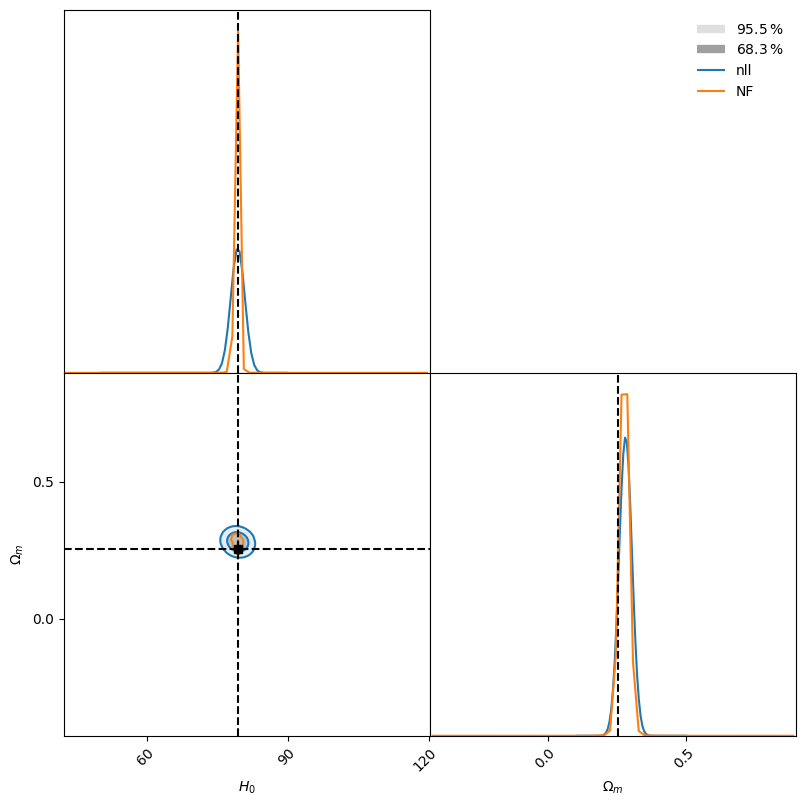

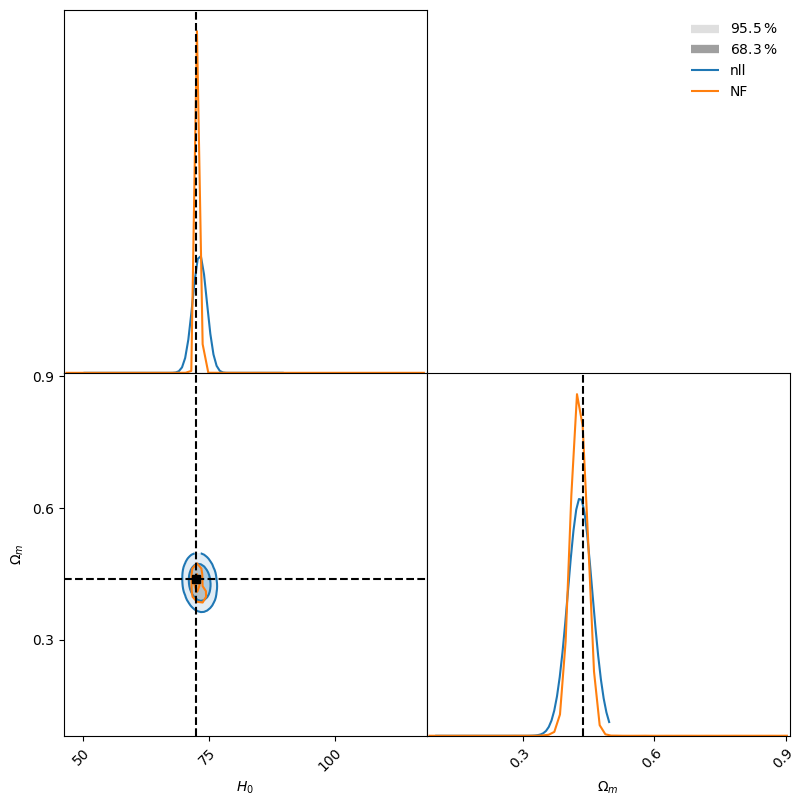

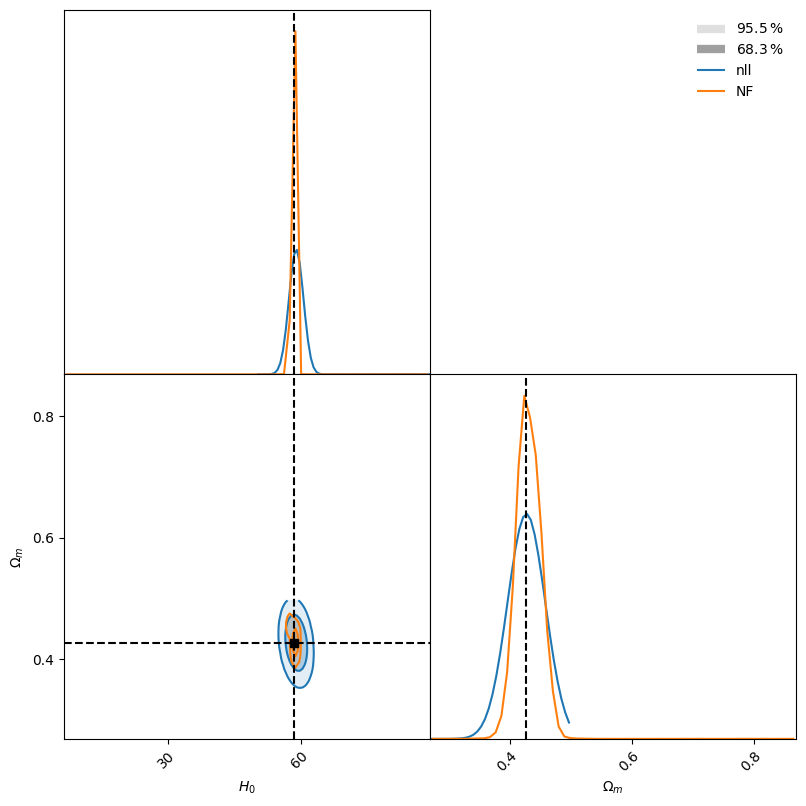

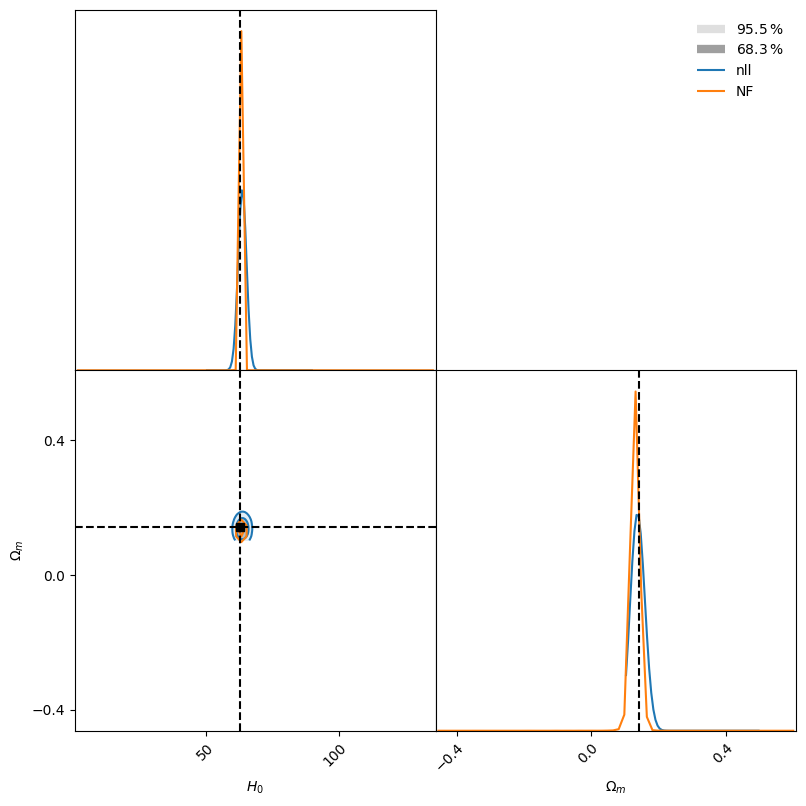

In [19]:
# import corner
from lampe.plots import corner, coverage_plot, mark_point, nice_rc

# ===== 推荐方案：叠加对比NLL和Flow =====
def plot_comparison_corner(sample_idx, nll_samples, flow_samples, true_values,
                          param_names=['$H_0$', '$\\Omega_m$']):
    """
    在同一个corner plot中叠加NLL和Flow的后验分布
    """
    figure = corner(
        nll_samples[sample_idx],
        smooth=2,
        domain=(LOWER, UPPER),
        creds=(0.6827, 0.9545),
        labels=param_names,
        legend=r'nll',
        figsize=(8, 8),
    )
    
    corner(
        flow_samples[sample_idx],
        creds= (0.6827, 0.9545),
        figure=figure,
        legend='NF'
    )
    
    mark_point(figure, true_values[sample_idx])
    
# ===== 使用方法 =====
# 为所有选定的测试样本绘制corner plot
for i, idx in enumerate(test_indices):
    plot_comparison_corner(
        sample_idx=i,
        nll_samples=nll_samples,
        flow_samples=flow_samples if flow_samples is not None else None,
        true_values=true_values,
        param_names=['$H_0$', '$\\Omega_m$']  # 根据你的参数调整
    )

## 8. 可靠性估计

一个校准良好的后验应该具有这样的属性：如果我们计算可信区间，真实值应该在大约X%的时间落在X%区间内。

In [20]:
def compute_coverage(samples, true_values, confidence_levels):
    n_test, n_samples, n_params = samples.shape
    
    coverage = {f'param_{i}': [] for i in range(n_params)}
    
    for level in confidence_levels:
        alpha = 1 - level
        lower_percentile = alpha / 2 * 100
        upper_percentile = (1 - alpha / 2) * 100
        
        for p in range(n_params):
            lower = np.percentile(samples[:, :, p], lower_percentile, axis=1)
            upper = np.percentile(samples[:, :, p], upper_percentile, axis=1)
            
            in_interval = (true_values[:, p] >= lower) & (true_values[:, p] <= upper)
            coverage[f'param_{p}'].append(in_interval.mean())
    
    return coverage

In [21]:
# 生成 samples for all test data
n_test_samples = min(500, len(X_test_t))  # Use subset for speed
test_subset_idx = np.random.choice(len(X_test_t), n_test_samples, replace=False)

X_test_subset = X_test_t[test_subset_idx].to(device)
theta_test_subset = theta_test_orig[test_subset_idx]

# NLL samples
nll_model.eval()
nll_samples_all = nll_model.sample(X_test_subset, n_samples=500)
nll_samples_all = nll_samples_all.cpu().numpy()
nll_samples_all = postprocess(nll_samples_all) #* theta_std + theta_mean

# Flow samples
flow_samples_all = []
for i in range(n_test_samples):
    flow_model.eval()
    flow_samples = flow_model.flow(X_test_subset[i].reshape((1,-1))).sample((500,))
    flow_samples = flow_samples.cpu().numpy()
    flow_samples = postprocess(flow_samples) #* theta_std + theta_mean
    flow_samples_all.append(flow_samples[:,0,:])
    
flow_samples_all = np.array(flow_samples_all)
print(f'Generated posterior samples for {n_test_samples} test cases')

Generated posterior samples for 500 test cases


In [22]:
# 计算 coverage
confidence_levels = np.linspace(0.1, 0.99, 20)

nll_coverage = compute_coverage(nll_samples_all, theta_test_subset, confidence_levels)

flow_coverage = compute_coverage(flow_samples_all, theta_test_subset, confidence_levels)

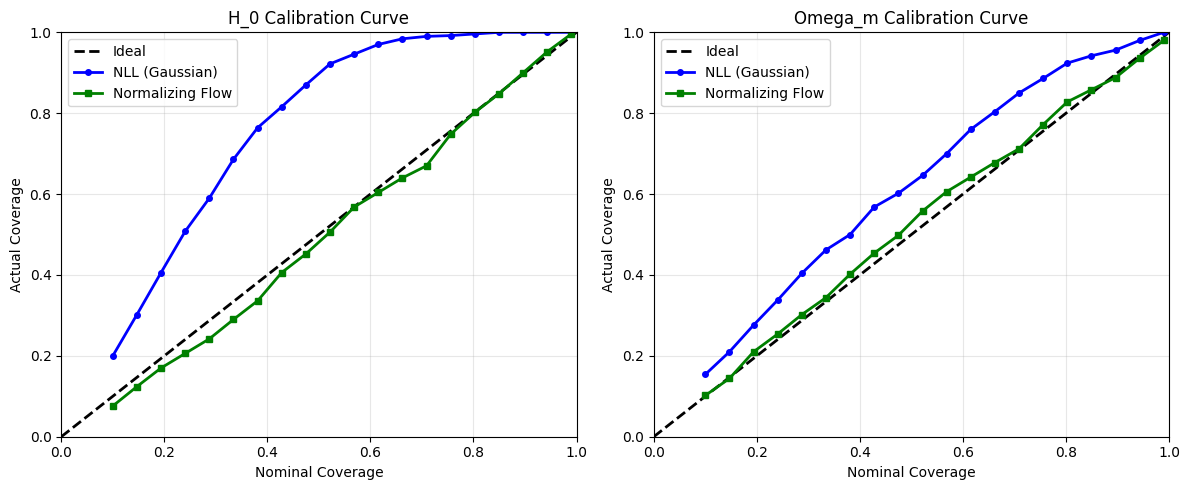

In [23]:
# 绘图 calibration curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

param_names = ['H_0', 'Omega_m']

for p, param_name in enumerate(param_names):
    ax = axes[p]
    
    # Ideal calibration
    ax.plot([0, 1], [0, 1], 'k--', label='Ideal', linewidth=2)
    
    # NLL coverage
    ax.plot(confidence_levels, nll_coverage[f'param_{p}'], 'b-o', 
            label='NLL (Gaussian)', linewidth=2, markersize=4)
    
    # Flow coverage
    if flow_coverage is not None:
        ax.plot(confidence_levels, flow_coverage[f'param_{p}'], 'g-s', 
                label='Normalizing Flow', linewidth=2, markersize=4)
    
    ax.set_xlabel('Nominal Coverage')
    ax.set_ylabel('Actual Coverage')
    ax.set_title(f'{param_name} Calibration Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Point Estimation Performance

In [24]:
# 计算 point estimates (posterior mean)
nll_point_estimates = nll_samples_all.mean(axis=1)

if flow_model is not None:
    flow_point_estimates = flow_samples_all.mean(axis=1)

# 计算 errors
nll_mae = np.abs(nll_point_estimates - theta_test_subset).mean(axis=0)
nll_rmse = np.sqrt(((nll_point_estimates - theta_test_subset)**2).mean(axis=0))

print('Point Estimation Performance (MAE, RMSE):')
print('-' * 50)
print(f'NLL (Gaussian):')
print(f'  Omega_m: MAE={nll_mae[0]:.4f}, RMSE={nll_rmse[0]:.4f}')
print(f'  w: MAE={nll_mae[1]:.4f}, RMSE={nll_rmse[1]:.4f}')

if flow_model is not None:
    flow_mae = np.abs(flow_point_estimates - theta_test_subset).mean(axis=0)
    flow_rmse = np.sqrt(((flow_point_estimates - theta_test_subset)**2).mean(axis=0))
    print(f'\nNormalizing Flow:')
    print(f'  Omega_m: MAE={flow_mae[0]:.4f}, RMSE={flow_rmse[0]:.4f}')
    print(f'  w: MAE={flow_mae[1]:.4f}, RMSE={flow_rmse[1]:.4f}')

Point Estimation Performance (MAE, RMSE):
--------------------------------------------------
NLL (Gaussian):
  Omega_m: MAE=0.3539, RMSE=0.4571
  w: MAE=0.0133, RMSE=0.0171

Normalizing Flow:
  Omega_m: MAE=0.2025, RMSE=0.2531
  w: MAE=0.0126, RMSE=0.0163


In [25]:
nll_samples_all.shape

(500, 500, 2)

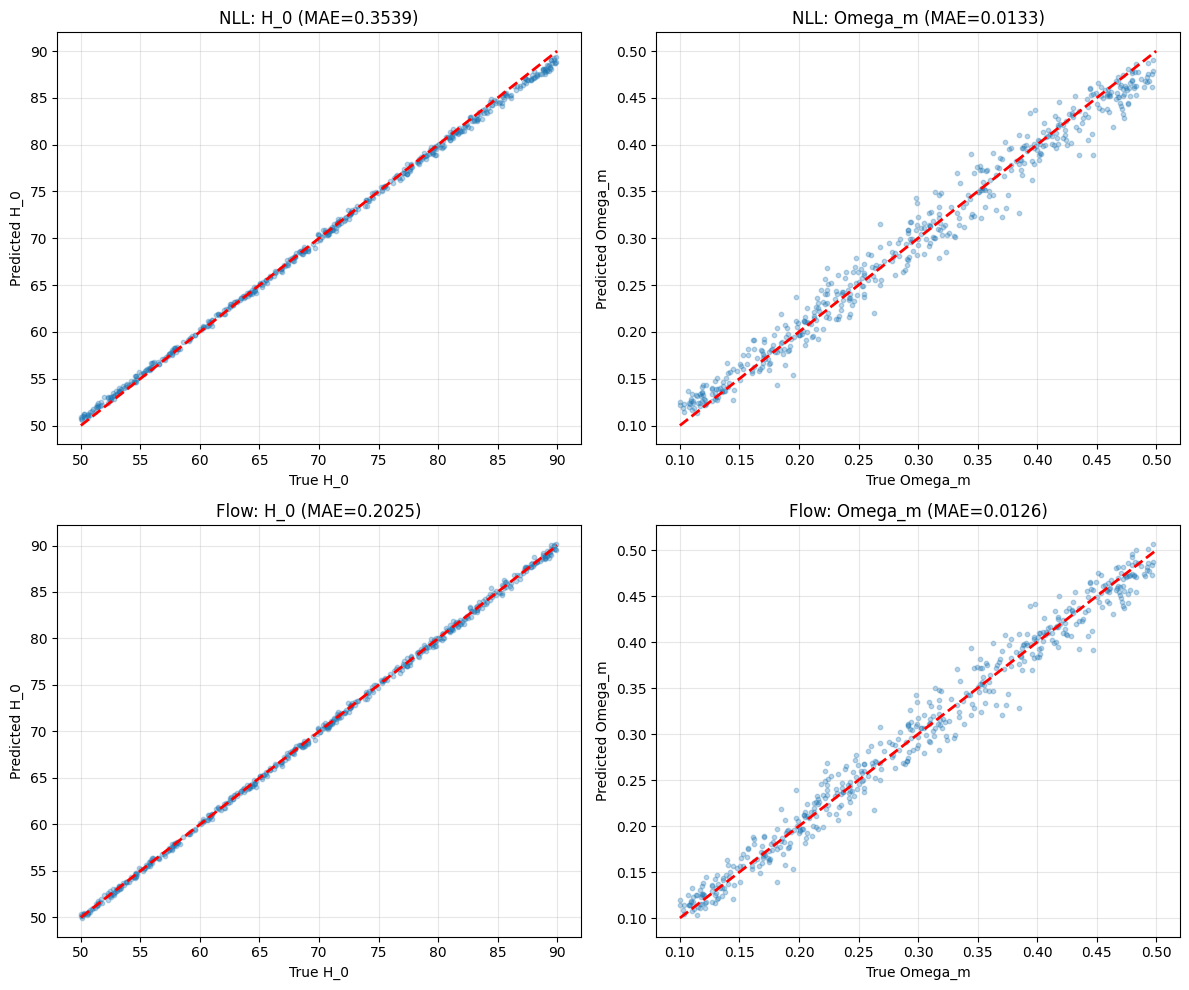

In [26]:
# 绘图 predicted vs true
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
param_ranges = [[H0_low, H0_up],[Om0_low, Om0_up]]

# NLL results
for p, param_name in enumerate(param_names):
    ax = axes[0, p]
    ax.scatter(theta_test_subset[:, p], nll_point_estimates[:, p], alpha=0.3, s=10)
    ax.plot(param_ranges[p], param_ranges[p], 'r--', linewidth=2)
    ax.set_xlabel(f'True {param_name}')
    ax.set_ylabel(f'Predicted {param_name}')
    ax.set_title(f'NLL: {param_name} (MAE={nll_mae[p]:.4f})')
    ax.grid(True, alpha=0.3)

# Flow results
if flow_model is not None:
    for p, param_name in enumerate(param_names):
        ax = axes[1, p]
        ax.scatter(theta_test_subset[:, p], flow_point_estimates[:, p], alpha=0.3, s=10)
        ax.plot(param_ranges[p], param_ranges[p], 'r--', linewidth=2)
        ax.set_xlabel(f'True {param_name}')
        ax.set_ylabel(f'Predicted {param_name}')
        ax.set_title(f'Flow: {param_name} (MAE={flow_mae[p]:.4f})')
        ax.grid(True, alpha=0.3)
else:
    for p in range(2):
        ax = axes[1, p]
        ax.text(0.5, 0.5, 'Not Available', ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title('Flow (N/A)')

plt.tight_layout()
plt.show()

## 10. Model Saving

In [27]:
# 保存 NLL model
torch.save({
    'model_state_dict': nll_model.state_dict(),
    'X_mean': X_mean,
    'X_std': X_std,
#     'theta_mean': theta_mean,
#     'theta_std': theta_std,
    'input_dim': input_dim,
    'output_dim': output_dim
}, 'sne_nll_model.pth')
print('NLL model saved to: sne_nll_model.pth')

# 保存 Flow model
if flow_model is not None:
    torch.save({
        'model_state_dict': flow_model.state_dict(),
        'X_mean': X_mean,
        'X_std': X_std,
#         'theta_mean': theta_mean,
#         'theta_std': theta_std,
        'input_dim': input_dim,
        'output_dim': output_dim
    }, 'sne_flow_model.pth')
    print('Flow model saved to: sne_flow_model.pth')

NLL model saved to: sne_nll_model.pth
Flow model saved to: sne_flow_model.pth


## 11. 总结和比较

### NLL（高斯假设）vs 归一化流比较

| 特征 | NLL（高斯） | 归一化流 |
|---------|----------------|-------------------|
| **分布假设** | 假设高斯后验 | 没有具体的假设 |
| **Output** | Mean and variance | 完整后验分布 |
| **多峰分布** | 无法捕捉 | 可以捕捉 |
| **非对称分布** | 无法捕捉 | 可以捕捉 |
| **参数相关性** | 假设独立 | 可以学习相关性 |
| **计算复杂度** | 低 | 较高 |
| **训练难度** | 简单 | 更复杂 |
| **使用场景** | 当后验近似为高斯分布时 | 复杂的多峰后验 |

### 选择指南：

1. **选择NLL（高斯）当**：
   - 后验分布已知近似为高斯分布
   - 需要快速推理
   - 参数近似独立
   - 计算资源有限

2. **选择归一化流当**：
   - 后验可能是多模态或不对称的
   - 参数之间存在复相关关系
   - 需要精确的不确定度量化
   - 有足够的数据

### zuko:

   - 简洁的API设计
   - 多个内置流架构（MAF， NSF等）
   - 无缝PyTorch集成
   - 针对基于模拟的推理（SBI）进行了优化